In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# ============================================================
# Width functions from the example
# ============================================================

def W_a1(p):
    """
    Width function for experiment a1 on domain p in [0.2, 0.9]:
        p                  if p in [0.2, 0.5]
        0.5                if p in (0.5, 0.6]
        1.1 - p            if p in (0.6, 0.9]
    """
    p = np.asarray(p)
    return np.where(
        p <= 0.5,
        p,
        np.where(p <= 0.6, 0.5, 1.1 - p)
    )


def W_a2(p):
    """
    Width function for experiment a2 on domain p in [0.3, 0.6]:
        0.1 + p            if p in [0.3, 0.4]
        0.5                if p in [0.4, 0.5]
        1 - p              if p in [0.5, 0.6]
    """
    p = np.asarray(p)
    return np.where(
        p <= 0.4,
        0.1 + p,
        np.where(p <= 0.5, 0.5, 1.0 - p)
    )


def L_a3(p1, p2):
    return np.maximum.reduce([
        np.zeros_like(p1),
        p1 - p2,
        0.5 - p2,
        p1 - 0.5
    ])


def U_a3(p1, p2):
    return np.minimum.reduce([
        p1,
        1.0 - p2,
        np.full_like(p1, 0.6),
        p1 - p2 + 0.4
    ])


def W_a3(p1, p2):
    return U_a3(p1, p2) - L_a3(p1, p2)


# ============================================================
# Plot styling
# ============================================================

plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "legend.fontsize": 10,
    "figure.dpi": 140
})


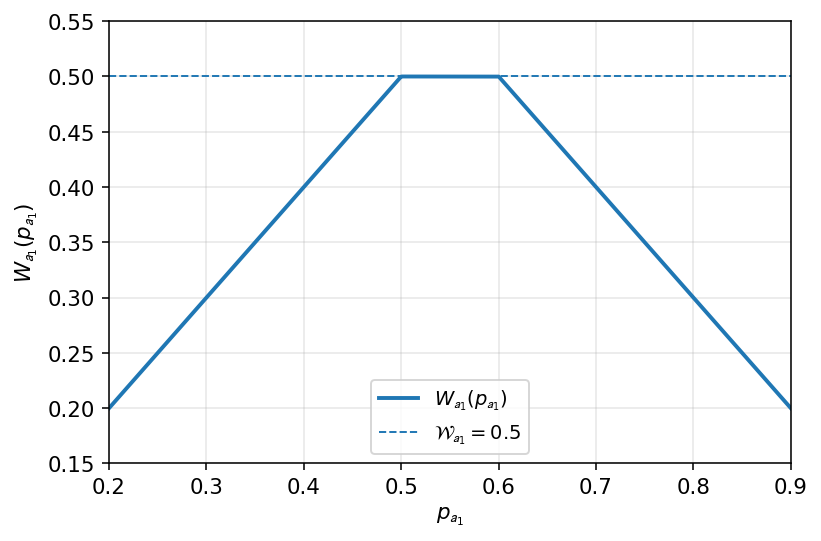

In [17]:

# ============================================================
# 1) 2D plot for a1
# ============================================================

p1_vals = np.linspace(0.2, 0.9, 1000)
w1_vals = W_a1(p1_vals)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(p1_vals, w1_vals, linewidth=2, label=r"$W_{\mathcal{a}_1}(p_{\mathcal{a}_1})$")
ax.axhline(0.5, linestyle="--", linewidth=1, label=r"$\mathcal{W}_{\mathcal{a}_1}=0.5$")
ax.set_xlabel(r"$p_{\mathcal{a}_1}$")
ax.set_ylabel(r"$W_{\mathcal{a}_1}(p_{\mathcal{a}_1})$")
# ax.set_title(r"Width function for experiment $\mathcal{a}_1$")
ax.set_xlim(0.2, 0.9)
ax.set_ylim(0.15, 0.55)
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig("Z1_W.png", bbox_inches="tight")
plt.show()



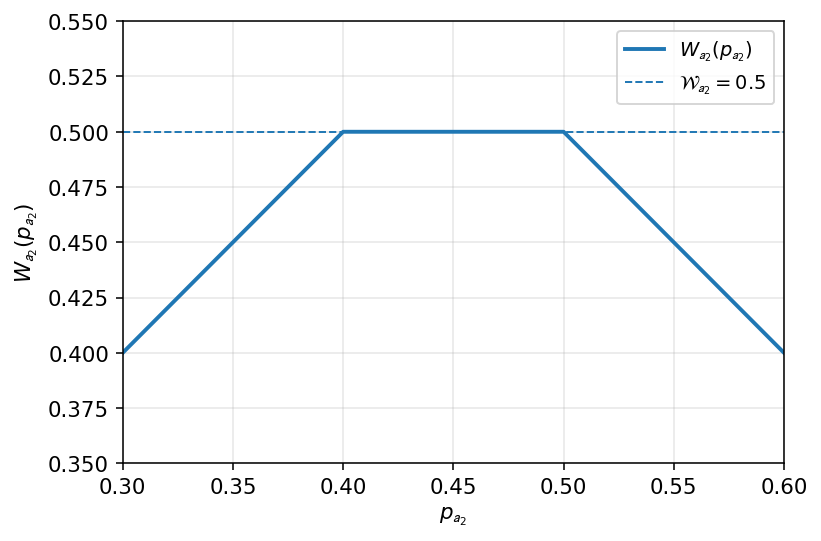

In [16]:

# ============================================================
# 2) 2D plot for a2
# ============================================================

p2_vals = np.linspace(0.3, 0.6, 1000)
w2_vals = W_a2(p2_vals)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(p2_vals, w2_vals, linewidth=2, label=r"$W_{\mathcal{a}_2}(p_{\mathcal{a}_2})$")
ax.axhline(0.5, linestyle="--", linewidth=1, label=r"$\mathcal{W}_{\mathcal{a}_2}=0.5$")
ax.set_xlabel(r"$p_{\mathcal{a}_2}$")
ax.set_ylabel(r"$W_{\mathcal{a}_2}(p_{\mathcal{a}_2})$")
# ax.set_title(r"Width function for experiment $\mathcal{a}_2$")
ax.set_xlim(0.3, 0.6)
ax.set_ylim(0.35, 0.55)
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig("Z2_W.png", bbox_inches="tight")
plt.show()



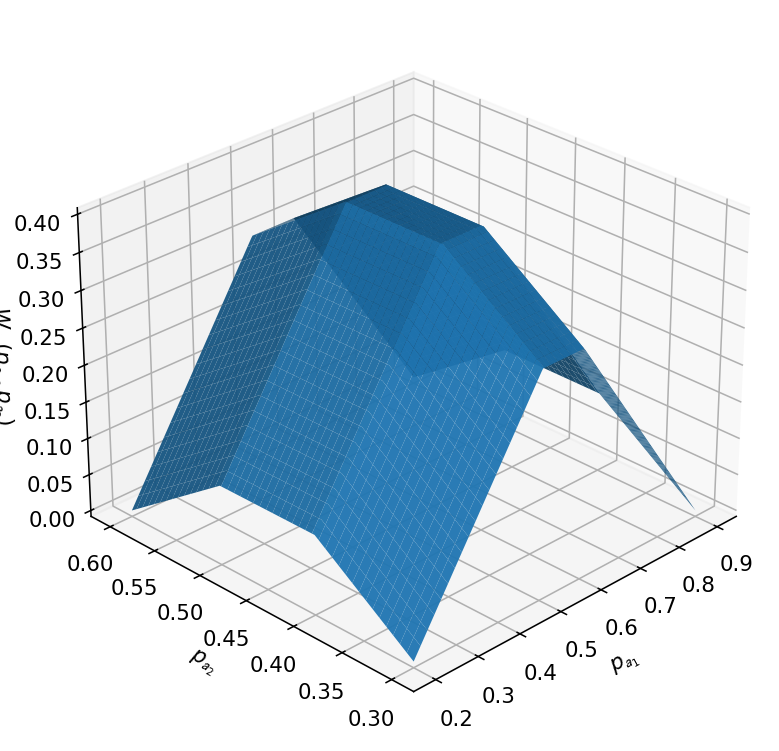

NameError: name 'w1_vals' is not defined

In [3]:

# ============================================================
# 3) 3D plot for a3
# ============================================================

p1_grid = np.linspace(0.2, 0.9, 220)
p2_grid = np.linspace(0.3, 0.6, 220)
P1, P2 = np.meshgrid(p1_grid, p2_grid)
W3 = W_a3(P1, P2)

fig = plt.figure(figsize=(7, 5.5))
ax = fig.add_subplot(111, projection="3d")
surf = ax.plot_surface(P1, P2, W3, linewidth=0, antialiased=True, alpha=0.95)

ax.set_xlabel(r"$p_{\mathcal{a}_1}$")
ax.set_ylabel(r"$p_{\mathcal{a}_2}$")
ax.set_zlabel(r"$W_{\mathcal{a}_3}(p_{\mathcal{a}_1},p_{\mathcal{a}_2})$")
# ax.set_title(r"Width function for experiment $\mathcal{a}_3 = \mathcal{a}_1 \cup \mathcal{a}_2$")
ax.view_init(elev=28, azim=-135)
plt.subplots_adjust(left=0.05, right=1.95, bottom=0.1, top=0.9)
plt.tight_layout()
plt.savefig("Z3_W.png", bbox_inches="tight", pad_inches=0.2)
plt.show()


# ============================================================
# Optional: print worst-case widths
# ============================================================

print("Worst-case width a1:", np.max(w1_vals))
print("Worst-case width a2:", np.max(w2_vals))
print("Worst-case width a3:", np.max(W3))